# Building an Othello Engine with Monte Carlo Tree Search
**EN.553.433 Monte Carlo Methods — Spring 2026 Final Project**  
Jason Chen, Raj Gosain, Ryan Wu

---

## Overview

This notebook implements a complete Othello (Reversi) engine with four AI bots of increasing difficulty,
culminating in a novel variant of Monte Carlo Tree Search (MCTS) that incorporates positional heuristics
and bitboard-accelerated game simulation.

**The four difficulty levels:**

| Level | Bot | Strategy |
|-------|-----|----------|
| Easy | `GreedyBot` | Maximises immediate disc captures, no lookahead |
| Medium | `HeuristicBot` | One-ply positional evaluation using a hand-crafted weight table |
| Hard | `MCTSHeuristicBot` | MCTS with heuristic-guided rollouts |
| Expert | `MCTSCombinedBot` | MCTS with heuristic expansion, corner-aware rollouts, and a TDL-trained value weight |

**Our novel contributions:**
1. **Progressive Heuristic Bias** — a positional bias term added to the UCT selection formula that fades as a node accumulates visits, injecting Othello-specific knowledge early in the search
2. **Bitboard optimisation** — the entire board is stored as two 64-bit integers, replacing Python list loops with bitwise operations for a measured 7.5× speedup on full MCTS runs

**Contents**
1. Game Engine — 64-bit bitboard implementation
2. Easy Bot — Greedy
3. Medium Bot — Heuristic
4. Hard Bots — MCTS variants
5. TDL Training — learning the value function weight
6. Simulation & Evaluation — head-to-head matchups
7. Presentation Visuals
8. Play a Game — Human vs Bot

## 1. Game Engine

The `Othello` class implements the complete game rules using **64-bit bitboards**.
Rather than storing the board as an 8×8 list of cells, the entire board state is encoded
in two Python integers — `black_bb` and `white_bb` — where each bit corresponds to one square
(bit index = row × 8 + col). A set bit means that player has a disc there.

This representation enables move generation, disc flipping, and game-over detection to be
performed using bitwise operations (AND, OR, shift) instead of Python loops, giving dramatic
speedups that directly translate to more MCTS simulations per second.

**Measured speedups vs. the original list-based engine:**

| Operation | Before | After | Speedup |
|-----------|--------|-------|---------|
| `get_legal_moves` | 5.56 µs | 1.04 µs | **5.4×** |
| `clone` | 2.73 µs | 0.18 µs | **15×** |
| Full MCTS (100 sims) | 1.59 s | 0.21 s | **7.5×** |

The public API (`get_legal_moves`, `apply_move`, `clone`, `board`) is identical
to a naive implementation, so all bots work without modification.


In [10]:
# ── Constants ──────────────────────────────────────────────────────────────────
EMPTY =  0   # empty square
BLACK =  1   # black player token
WHITE = -1   # white player token

# ── Bitboard helpers ────────────────────────────────────────────────────────────
# A 64-bit mask with all bits set (represents every square on the board)
_ALL_SQUARES = (1 << 64) - 1

# Column-edge masks prevent wrap-around when shifting horizontally.
# _NO_COL_A masks out column 0 (leftmost); _NO_COL_H masks out column 7 (rightmost).
_NO_COL_A = 0xFEFEFEFEFEFEFEFE
_NO_COL_H = 0x7F7F7F7F7F7F7F7F

# Each direction is represented as (bit_shift, wrap_mask).
# Positive shift = move East/South in board space.
# The wrap mask prevents bits from wrapping across board edges.
_DIRECTIONS = [
    ( 1, _NO_COL_H),  # East
    (-1, _NO_COL_A),  # West
    ( 8, _ALL_SQUARES),  # South
    (-8, _ALL_SQUARES),  # North
    ( 9, _NO_COL_H),  # South-East
    (-9, _NO_COL_A),  # North-West
    ( 7, _NO_COL_A),  # South-West
    (-7, _NO_COL_H),  # North-East
]


def _shift(bitboard: int, direction: int, wrap_mask: int) -> int:
    """
    Shift all bits in `bitboard` by `direction` positions, applying `wrap_mask`
    to prevent bits from wrapping around the board edges.

    Args:
        bitboard: Integer representing a set of board squares.
        direction: Number of bit positions to shift (positive = right/south).
        wrap_mask: Bitmask to prevent edge wraparound.

    Returns:
        Shifted and masked bitboard as an integer.
    """
    if direction > 0:
        return (bitboard >> direction) & wrap_mask
    return (bitboard << (-direction)) & wrap_mask & _ALL_SQUARES


def _legal_moves_bb(my_bb: int, opp_bb: int) -> int:
    """
    Compute all legal moves for the player whose discs are in `my_bb`,
    using a sliding fill technique in all 8 directions.

    A legal move must land on an empty square and bracket at least one
    opponent disc between the new disc and an existing friendly disc.

    Args:
        my_bb: Bitboard of the current player's discs.
        opp_bb: Bitboard of the opponent's discs.

    Returns:
        Bitboard where each set bit is a legal move square.
    """
    empty_squares = ~(my_bb | opp_bb) & _ALL_SQUARES
    legal_moves = 0
    for direction, wrap_mask in _DIRECTIONS:
        # Start with squares one step in this direction that contain opponent discs
        sliding_front = _shift(my_bb, direction, wrap_mask) & opp_bb
        # Extend the chain through consecutive opponent discs (up to 6 in a row)
        for _ in range(5):
            sliding_front |= _shift(sliding_front, direction, wrap_mask) & opp_bb
        # The square one step past the chain must be empty to be a legal move
        legal_moves |= _shift(sliding_front, direction, wrap_mask) & empty_squares
    return legal_moves


def _flip_discs_bb(move_bit: int, my_bb: int, opp_bb: int):
    """
    Apply a move and compute the resulting disc flip.

    Slides outward from the placed disc in all 8 directions,
    collecting opponent discs that are bracketed by a friendly disc.

    Args:
        move_bit: Bitboard with exactly one bit set — the square being played.
        my_bb: Current player's disc bitboard before the move.
        opp_bb: Opponent's disc bitboard before the move.

    Returns:
        Tuple (new_my_bb, new_opp_bb) after flipping all captured discs.
    """
    flipped = 0
    for direction, wrap_mask in _DIRECTIONS:
        candidates = _shift(move_bit, direction, wrap_mask) & opp_bb
        for _ in range(5):
            candidates |= _shift(candidates, direction, wrap_mask) & opp_bb
        # Only flip if the chain is bounded by one of our own discs
        if _shift(candidates, direction, wrap_mask) & my_bb:
            flipped |= candidates
    return my_bb | move_bit | flipped, opp_bb & ~flipped


def _bitboard_to_moves(bitboard: int):
    """
    Convert a bitboard of legal move squares into a list of (row, col) tuples.

    Uses the least-significant-bit trick to iterate over set bits efficiently.

    Args:
        bitboard: Integer with one bit set per legal move square.

    Returns:
        List of (row, col) tuples, 0-indexed.
    """
    moves = []
    while bitboard:
        lsb = bitboard & (-bitboard)       # isolate lowest set bit
        bit_index = lsb.bit_length() - 1  # convert to square index
        moves.append((bit_index >> 3, bit_index & 7))  # row = index//8, col = index%8
        bitboard &= bitboard - 1           # clear lowest set bit
    return moves


class Othello:
    """
    Complete Othello (Reversi) game engine using 64-bit bitboards.

    The board is stored as two integers:
        black_bb — one bit set per BLACK disc (bit index = row*8 + col)
        white_bb — one bit set per WHITE disc

    All move generation, flipping, and game-over checks are pure bitwise
    operations with no per-cell Python loops, enabling fast MCTS simulation.

    Public API:
        get_legal_moves(player) -> list of (row, col)
        apply_move(move, player) — mutates board in place
        clone() -> Othello          — fast 3-integer copy
        board -> 8x8 list           — human-readable view
        is_game_over() -> bool
        get_winner() -> BLACK | WHITE | 0
        get_score() -> dict with 'black' and 'white' disc counts
        print_board()               — ASCII display
    """

    # __slots__ avoids per-instance __dict__, saving memory for MCTS tree nodes
    __slots__ = ('black_bb', 'white_bb', 'current_player')

    def __init__(self):
        """Initialise the standard Othello starting position."""
        # Standard starting position: two black and two white discs in the centre
        self.black_bb = (1 << (3*8+4)) | (1 << (4*8+3))
        self.white_bb = (1 << (3*8+3)) | (1 << (4*8+4))
        self.current_player = BLACK

    @property
    def board(self):
        """
        Return an 8×8 list-of-lists view of the board.

        Each cell contains BLACK (1), WHITE (-1), or EMPTY (0).
        This is used by the heuristic evaluator and for display.
        The fast bitboard path skips this property entirely.
        """
        grid = [[EMPTY] * 8 for _ in range(8)]
        bb = self.black_bb
        while bb:
            lsb = bb & (-bb)
            idx = lsb.bit_length() - 1
            grid[idx >> 3][idx & 7] = BLACK
            bb &= bb - 1
        bb = self.white_bb
        while bb:
            lsb = bb & (-bb)
            idx = lsb.bit_length() - 1
            grid[idx >> 3][idx & 7] = WHITE
            bb &= bb - 1
        return grid

    def clone(self):
        """
        Return a deep copy of this game state.

        Implemented as three integer assignments — 15× faster than copying
        a list-of-lists board. Called thousands of times per MCTS search.
        """
        copy = Othello.__new__(Othello)
        copy.black_bb = self.black_bb
        copy.white_bb = self.white_bb
        copy.current_player = self.current_player
        return copy

    def in_bounds(self, row: int, col: int) -> bool:
        """Return True if (row, col) is a valid board position."""
        return 0 <= row < 8 and 0 <= col < 8

    def _my_and_opp_bb(self, player: int):
        """Return (my_bb, opp_bb) for the given player."""
        if player == BLACK:
            return self.black_bb, self.white_bb
        return self.white_bb, self.black_bb

    def get_legal_moves(self, player=None):
        """
        Return a list of legal (row, col) moves for `player`.

        Args:
            player: BLACK or WHITE. Defaults to the current player.

        Returns:
            List of (row, col) tuples. Empty list if the player must pass.
        """
        if player is None:
            player = self.current_player
        return _bitboard_to_moves(_legal_moves_bb(*self._my_and_opp_bb(player)))

    def apply_move(self, move, player=None):
        """
        Apply `move` to the board, flipping opponent discs as required.

        Args:
            move: (row, col) tuple, or None to pass.
            player: BLACK or WHITE. Defaults to the current player.
        """
        if player is None:
            player = self.current_player
        if move is None:
            self.current_player = -player
            return
        row, col = move
        my_bb, opp_bb = self._my_and_opp_bb(player)
        new_my_bb, new_opp_bb = _flip_discs_bb(1 << (row * 8 + col), my_bb, opp_bb)
        if player == BLACK:
            self.black_bb, self.white_bb = new_my_bb, new_opp_bb
        else:
            self.white_bb, self.black_bb = new_my_bb, new_opp_bb
        self.current_player = -player

    def has_any_moves(self, player: int) -> bool:
        """Return True if `player` has at least one legal move."""
        return bool(_legal_moves_bb(*self._my_and_opp_bb(player)))

    def is_game_over(self) -> bool:
        """Return True if neither player has any legal moves."""
        return not self.has_any_moves(BLACK) and not self.has_any_moves(WHITE)

    def get_winner(self) -> int:
        """
        Return the winner: BLACK, WHITE, or 0 for a draw.

        Determined by disc count at game end.
        """
        black_count = bin(self.black_bb).count('1')
        white_count = bin(self.white_bb).count('1')
        if black_count > white_count:
            return BLACK
        if white_count > black_count:
            return WHITE
        return 0

    def get_score(self) -> dict:
        """Return {'black': int, 'white': int} disc counts."""
        return {
            'black': bin(self.black_bb).count('1'),
            'white': bin(self.white_bb).count('1'),
        }

    def print_board(self):
        """Print an ASCII representation of the board to stdout."""
        symbols = {BLACK: 'B', WHITE: 'W', EMPTY: '.'}
        grid = self.board
        print('  0 1 2 3 4 5 6 7')
        for row in range(8):
            print(f'{row} ' + ' '.join(symbols[grid[row][col]] for col in range(8)))


# ── Sanity check ───────────────────────────────────────────────────────────────
print('Bitboard Othello engine loaded.')
print(f'Starting legal moves: {sorted(Othello().get_legal_moves())}')


Bitboard Othello engine loaded.
Starting legal moves: [(2, 3), (3, 2), (4, 5), (5, 4)]


## 2. Easy Bot — Greedy

`GreedyBot` uses the simplest possible strategy: at each turn, pick whichever legal move
immediately flips the most opponent discs. There is no lookahead — the bot is entirely
reactive and cannot reason about future consequences.

Despite its simplicity, GreedyBot provides a useful baseline. Interestingly, it wins 50% of
games against the more sophisticated HeuristicBot — demonstrating that raw disc count is a
poor proxy for overall game strength.


In [11]:
class GreedyBot:
    """
    Easy difficulty bot. Selects the move that captures the most discs immediately.

    Strategy: one-ply greedy search — no tree search, no positional reasoning.
    Complexity: O(m) per move where m is the number of legal moves.
    """

    def choose_move(self, game: Othello, player: int = None):
        """
        Choose the legal move that maximises the current player's disc count
        after the move is applied.

        Args:
            game: Current Othello game state.
            player: BLACK or WHITE. Defaults to game.current_player.

        Returns:
            (row, col) tuple of the chosen move, or None if no moves are available.
        """
        if player is None:
            player = game.current_player
        legal_moves = game.get_legal_moves(player)
        if not legal_moves:
            return None

        best_move = None
        best_disc_count = float("-inf")

        for move in legal_moves:
            # Simulate the move and count our discs in the resulting state
            candidate_game = game.clone()
            candidate_game.apply_move(move, player)
            disc_count = sum(
                cell == player
                for row in candidate_game.board
                for cell in row
            )
            if disc_count > best_disc_count:
                best_disc_count = disc_count
                best_move = move

        return best_move


print("GreedyBot (Easy) loaded.")


GreedyBot (Easy) loaded.


## 3. Medium Bot — Heuristic

`HeuristicBot` replaces raw disc count with a hand-crafted **position weight table**,
assigning a strategic value to each of the 64 squares. Key values:

| Zone | Value | Rationale |
|------|-------|-----------|
| Corners | +100 | Permanently stable, can never be flipped |
| X-squares (diagonal to corners) | −50 | Playing here often gifts the opponent a corner |
| C-squares (edge-adjacent to corners) | −20 | Similar risk to X-squares |
| Edges | +5 to +10 | Stable once anchored to a corner |
| Interior | −1 to −2 | Easy to flip, low long-term value |

The bot also adds a **mobility bonus** — 5 points per extra legal move available to us
versus the opponent. Mobility (number of legal moves) is a strong positional indicator
in Othello.

This is still a one-ply evaluation — no tree search — but it beats GreedyBot decisively
on average disc margin while tying it on win rate.


In [12]:
# Position weight table: assigns a strategic value to each board square.
# Indexed as POSITION_WEIGHTS[row][col].
POSITION_WEIGHTS = [
    [100, -20,  10,   5,   5,  10, -20, 100],
    [-20, -50,  -2,  -2,  -2,  -2, -50, -20],
    [ 10,  -2,  -1,  -1,  -1,  -1,  -2,  10],
    [  5,  -2,  -1,  -1,  -1,  -1,  -2,   5],
    [  5,  -2,  -1,  -1,  -1,  -1,  -2,   5],
    [ 10,  -2,  -1,  -1,  -1,  -1,  -2,  10],
    [-20, -50,  -2,  -2,  -2,  -2, -50, -20],
    [100, -20,  10,   5,   5,  10, -20, 100],
]

# Precomputed flat lookup: _PW_FLAT[bit_index] = positional weight for that square.
# Avoids the .board property during fast bitboard scoring.
_PW_FLAT = [POSITION_WEIGHTS[i >> 3][i & 7] for i in range(64)]


class HeuristicBot:
    """
    Medium difficulty bot. One-ply evaluation using positional weights and mobility.

    At each turn, every legal move is simulated and scored using:
        score = positional_weight_sum + 5 * (our_mobility - opponent_mobility)

    No tree search — purely reactive like GreedyBot, but with stronger positional
    awareness. Wins the same number of games as GreedyBot (50%) but by a much
    larger average disc margin, showing it plays better Othello even when it can't
    consistently convert that into wins at this game count.
    """

    def choose_move(self, game: Othello, player: int = None):
        """
        Choose the move with the highest one-ply heuristic score.

        Args:
            game: Current Othello game state.
            player: BLACK or WHITE. Defaults to game.current_player.

        Returns:
            (row, col) tuple of the chosen move, or None if no moves available.
        """
        if player is None:
            player = game.current_player
        legal_moves = game.get_legal_moves(player)
        if not legal_moves:
            return None

        best_move = None
        best_score = float("-inf")

        for move in legal_moves:
            candidate_game = game.clone()
            candidate_game.apply_move(move, player)
            score = self._evaluate_position(candidate_game, player)
            if score > best_score:
                best_score = score
                best_move = move

        return best_move

    def _evaluate_position(self, game: Othello, player: int) -> float:
        """
        Score a board position for `player` using positional weights and mobility.

        Args:
            game: Board state after a candidate move has been applied.
            player: The player we are optimising for.

        Returns:
            Scalar score — higher is better for `player`.
        """
        positional_score = 0
        for row in range(8):
            for col in range(8):
                cell = game.board[row][col]
                if cell == player:
                    positional_score += POSITION_WEIGHTS[row][col]
                elif cell == -player:
                    positional_score -= POSITION_WEIGHTS[row][col]

        # Mobility: reward having more legal moves than the opponent
        our_mobility = len(game.get_legal_moves(player))
        opp_mobility = len(game.get_legal_moves(-player))
        mobility_bonus = 5 * (our_mobility - opp_mobility)

        return positional_score + mobility_bonus


def _bb_heuristic_score(game: Othello, player: int) -> int:
    """
    Fast bitboard-based positional score (no .board property access).

    Identical in output to HeuristicBot._evaluate_position's positional term
    but reads directly from the bitboards, making it suitable for use inside
    MCTS rollouts where speed is critical.

    Args:
        game: Current Othello game state.
        player: The player we are scoring for.

    Returns:
        Integer positional score — higher is better for `player`.
    """
    score = 0
    my_bb  = game.black_bb if player == BLACK else game.white_bb
    opp_bb = game.white_bb if player == BLACK else game.black_bb

    bb = my_bb
    while bb:
        lsb = bb & (-bb)
        score += _PW_FLAT[lsb.bit_length() - 1]
        bb &= bb - 1

    bb = opp_bb
    while bb:
        lsb = bb & (-bb)
        score -= _PW_FLAT[lsb.bit_length() - 1]
        bb &= bb - 1

    return score


print("HeuristicBot (Medium) loaded.")


HeuristicBot (Medium) loaded.


## 4. Hard Bots — MCTS Variants

All MCTS bots share the same **Upper Confidence Bound for Trees (UCT)** tree structure.
They differ only in how they perform rollouts and how they guide tree expansion.

### The MCTS Algorithm

Each call to `choose_move` runs a fixed number of simulations, each consisting of four steps:

1. **Selection** — Starting from the root (current board state), repeatedly select the child
   with the highest UCT score until an unexpanded or terminal node is reached.

2. **Expansion** — Add one new child node by trying an untried move.

3. **Simulation (Rollout)** — Play out the rest of the game from the new node using a fast
   policy (random, heuristic, or value function) to get a win/loss result.

4. **Backpropagation** — Update the visit count and win count of every node along the
   path from the expanded node back to the root.

After all simulations, the move with the **most visits** is selected (not highest win rate —
visit count is more robust to variance).

### UCT Selection Formula

The score used to select which child to visit during the selection phase is:

$$\text{score} = \underbrace{\frac{w_i}{n_i}}_{\text{exploitation}} + \underbrace{c\sqrt{\frac{\ln N_i}{n_i}}}_{\text{exploration}}$$

where $w_i$ = wins through node $i$, $n_i$ = visits to node $i$, $N_i$ = visits to the parent,
and $c = 1.4 \approx \sqrt{2}$ is the exploration constant from the UCB1 paper.

### Our Novel Contribution: Progressive Heuristic Bias

We extend the UCT formula with a third term that injects positional knowledge early in the search:

$$\text{score} = \frac{w_i}{n_i} + c\sqrt{\frac{\ln N_i}{n_i}} + \beta \cdot \frac{PW[r,c]}{\text{visits} + 1}$$

The bias term uses the same position weight table as the Medium bot. As a node accumulates
visits, the denominator grows and the bias shrinks toward zero — so the positional prior fades
naturally once the win-rate estimate becomes statistically reliable.

### MCTS Variants

| Bot | Rollout | Expansion | Simulations |
|-----|---------|-----------|-------------|
| `MCTSBot` | Random (corner-greedy) | Standard | 200 |
| `MCTSHeuristicBot` | Full heuristic | Standard | 200 |
| `MCTSTDLBot` | TDL value function | Standard | 200 |
| `MCTSCombinedBot` (Expert) | Corner-greedy | Heuristic-guided | 500 |


In [13]:
import math
import random


class MCTSNode:
    """
    A single node in the MCTS search tree.

    Each node represents a game state reached by playing `move` from the parent.
    Tracks visit count and accumulated wins for the UCT formula.

    Attributes:
        state: The Othello game state at this node.
        parent: Parent MCTSNode, or None for the root.
        move: The move that led to this state from the parent.
        root_player: The player we are optimising for (BLACK or WHITE).
        children: List of expanded child MCTSNodes.
        untried_moves: Legal moves not yet expanded into child nodes.
        visits: Number of times this node has been visited.
        wins: Accumulated win score backpropagated through this node.
    """

    def __init__(self, state: Othello, parent=None, move=None, root_player: int = None):
        """
        Initialise a new MCTS node.

        Args:
            state: Game state at this node.
            parent: Parent node (None for root).
            move: Move that produced this state.
            root_player: Player we are optimising for.
        """
        self.state = state
        self.parent = parent
        self.move = move
        self.root_player = root_player
        self.children = []
        self.visits = 0
        self.wins = 0.0

        # Untried moves are all legal moves not yet expanded.
        # If no legal moves exist but the game is not over, a pass (None) is added.
        legal_moves = state.get_legal_moves()
        if legal_moves:
            self.untried_moves = legal_moves
        elif not state.is_game_over():
            self.untried_moves = [None]  # forced pass
        else:
            self.untried_moves = []

    def is_fully_expanded(self) -> bool:
        """Return True if all legal moves have been expanded into child nodes."""
        return len(self.untried_moves) == 0

    def best_child(self, exploration_constant: float = 1.4) -> 'MCTSNode':
        """
        Select the child with the highest UCT score.

        Unvisited children receive a score of infinity to guarantee they are
        explored before any child is visited twice.

        Args:
            exploration_constant: UCB1 exploration parameter c (default √2 ≈ 1.4).

        Returns:
            The child MCTSNode with the highest UCT score.
        """
        best_score = float("-inf")
        best_children = []

        for child in self.children:
            if child.visits == 0:
                uct_score = float("inf")
            else:
                exploitation = child.wins / child.visits
                exploration = exploration_constant * math.sqrt(
                    math.log(self.visits) / child.visits
                )
                uct_score = exploitation + exploration

            if uct_score > best_score:
                best_score = uct_score
                best_children = [child]
            elif uct_score == best_score:
                best_children.append(child)

        return random.choice(best_children)

    def expand(self, move_selector=None) -> 'MCTSNode':
        """
        Expand one untried move into a new child node.

        Args:
            move_selector: Optional callable that takes the untried_moves list
                and returns the index of the move to expand. If None, the last
                move in the list is popped (arbitrary order).

        Returns:
            The newly created child MCTSNode.
        """
        if move_selector is not None:
            idx = move_selector(self.untried_moves)
            move = self.untried_moves.pop(idx)
        else:
            move = self.untried_moves.pop()

        next_state = self.state.clone()
        next_state.apply_move(move)
        child = MCTSNode(
            state=next_state,
            parent=self,
            move=move,
            root_player=self.root_player
        )
        self.children.append(child)
        return child


def _backpropagate(node: MCTSNode, result: float):
    """
    Walk from `node` up to the root, incrementing visit counts and adding
    the simulation result to each node's win total.

    Args:
        node: The leaf node where simulation ended.
        result: Win score (1.0 = win, 0.5 = draw, 0.0 = loss) for root_player.
    """
    while node is not None:
        node.visits += 1
        node.wins += result
        node = node.parent


def _run_mcts(
    game: Othello,
    num_simulations: int,
    exploration_constant: float,
    rollout_fn,
    expand_selector=None
):
    """
    Core MCTS loop: build a search tree and return the best move.

    Runs `num_simulations` iterations of Selection → Expansion → Simulation →
    Backpropagation, then returns the child of the root with the most visits.

    Args:
        game: Current game state (not modified).
        num_simulations: Number of MCTS iterations to run.
        exploration_constant: UCB1 c parameter passed to best_child().
        rollout_fn: Callable(state, root_player) -> float that plays out a game
            from `state` and returns a win score in [0, 1] for root_player.
        expand_selector: Optional callable passed to MCTSNode.expand() to
            control which untried move is expanded first.

    Returns:
        (row, col) of the recommended move, or None if no moves are available.
    """
    root_player = game.current_player
    root = MCTSNode(state=game.clone(), root_player=root_player)

    for _ in range(num_simulations):
        node = root

        # Selection: traverse tree using UCT until a non-fully-expanded or terminal node
        while (not node.state.is_game_over()
               and node.is_fully_expanded()
               and node.children):
            node = node.best_child(exploration_constant)

        # Expansion: add one new child if the node is not terminal
        if not node.state.is_game_over() and not node.is_fully_expanded():
            node = node.expand(expand_selector)

        # Simulation: play out the game from the new node
        simulation_result = rollout_fn(node.state.clone(), root_player)

        # Backpropagation: update all nodes along the path
        _backpropagate(node, simulation_result)

    if not root.children:
        return None
    # Return the move with the most visits (most robust estimate)
    return max(root.children, key=lambda child: child.visits).move


# ── TDL value function helpers ─────────────────────────────────────────────────
# Used by MCTSTDLBot and MCTSCombinedBot to evaluate positions without rollout.

# A second weight table used by the TDL value function (slightly different from
# POSITION_WEIGHTS: interior squares use small positive values rather than -1).
SQUARE_WEIGHTS = [
    [ 100, -20,  10,  5,  5,  10, -20,  100],
    [ -20, -50,  -2, -2, -2,  -2, -50,  -20],
    [  10,  -2,   5,  1,  1,   5,  -2,   10],
    [   5,  -2,   1,  0,  0,   1,  -2,    5],
    [   5,  -2,   1,  0,  0,   1,  -2,    5],
    [  10,  -2,   5,  1,  1,   5,  -2,   10],
    [ -20, -50,  -2, -2, -2,  -2, -50,  -20],
    [ 100, -20,  10,  5,  5,  10, -20,  100],
]
# Normalisation constant for board score
_MAX_BOARD_SCORE = sum(abs(SQUARE_WEIGHTS[r][c]) for r in range(8) for c in range(8))


def _board_score(game: Othello, player: int) -> float:
    """
    Compute a normalised positional score in [-1, 1] for `player`.

    Uses SQUARE_WEIGHTS summed over all occupied squares, normalised by
    the theoretical maximum score.

    Args:
        game: Current board state.
        player: Player to score for.

    Returns:
        Float in [-1, 1] where positive means a strong position for `player`.
    """
    raw_score = sum(
        SQUARE_WEIGHTS[r][c] * (
            1 if game.board[r][c] == player
            else -1 if game.board[r][c] == -player
            else 0
        )
        for r in range(8) for c in range(8)
    )
    return raw_score / _MAX_BOARD_SCORE


def _sigmoid(x: float) -> float:
    """
    Numerically stable sigmoid function, clamped to avoid overflow.

    Args:
        x: Input value.

    Returns:
        sigmoid(x) in (0, 1).
    """
    x = max(-20.0, min(20.0, x))
    return 1.0 / (1.0 + math.exp(-x))


def _predict_win_probability(game: Othello, player: int, weight: float) -> float:
    """
    Estimate win probability for `player` using the TDL value function.

    The value function is sigmoid(weight * board_score), where `weight` is
    a scalar learned via TD(1) self-play training (see Section 5).

    Args:
        game: Current board state.
        player: Player to evaluate for.
        weight: Learned TDL scalar weight.

    Returns:
        Estimated win probability in (0, 1).
    """
    return _sigmoid(weight * _board_score(game, player))


# ── 4a. MCTSBot — random rollout, corner-aware ─────────────────────────────────
class MCTSBot:
    """
    Baseline MCTS bot with corner-aware random rollout.

    During rollouts, if a corner square is available it is always taken.
    Otherwise a random legal move is played. This is the simplest MCTS variant
    and serves as the baseline for comparison.

    Default: 200 simulations per move, c = 1.4.
    """

    CORNER_SQUARES = {(0, 0), (0, 7), (7, 0), (7, 7)}

    def __init__(self, num_simulations: int = 200, exploration_constant: float = 1.4):
        """
        Args:
            num_simulations: MCTS iterations per move.
            exploration_constant: UCB1 c parameter.
        """
        self.num_simulations = num_simulations
        self.exploration_constant = exploration_constant

    def choose_move(self, game: Othello, player: int = None):
        """
        Run MCTS and return the recommended move.

        Args:
            game: Current game state.
            player: Not used directly (MCTS uses game.current_player internally).

        Returns:
            (row, col) of the best move found.
        """
        return _run_mcts(
            game, self.num_simulations, self.exploration_constant, self._rollout
        )

    def _rollout(self, state: Othello, root_player: int) -> float:
        """
        Play out the game randomly, always grabbing corners when available.

        Args:
            state: Board state to simulate from (modified in place).
            root_player: The player we are scoring for.

        Returns:
            1.0 (win), 0.5 (draw), or 0.0 (loss) for root_player.
        """
        while not state.is_game_over():
            legal_moves = state.get_legal_moves()
            if not legal_moves:
                state.apply_move(None)
                continue
            corner_moves = [m for m in legal_moves if m in self.CORNER_SQUARES]
            chosen_move = (
                random.choice(corner_moves) if corner_moves
                else random.choice(legal_moves)
            )
            state.apply_move(chosen_move)

        winner = state.get_winner()
        return 1.0 if winner == root_player else (0.5 if winner == 0 else 0.0)


# ── 4b. MCTSHeuristicBot — full heuristic rollout (Hard difficulty) ─────────────
class MCTSHeuristicBot:
    """
    MCTS with a greedy heuristic rollout policy (Hard difficulty).

    During rollouts, instead of playing randomly, each move is chosen by
    maximising the positional score using the POSITION_WEIGHTS table.
    This produces more realistic simulations and a stronger win-rate signal,
    especially at low simulation counts.

    Default: 200 simulations per move, c = 1.4.
    """

    def __init__(self, num_simulations: int = 200, exploration_constant: float = 1.4):
        """
        Args:
            num_simulations: MCTS iterations per move.
            exploration_constant: UCB1 c parameter.
        """
        self.num_simulations = num_simulations
        self.exploration_constant = exploration_constant

    def choose_move(self, game: Othello, player: int = None):
        """
        Run MCTS with heuristic rollout and return the recommended move.

        Args:
            game: Current game state.
            player: Unused (MCTS uses game.current_player internally).

        Returns:
            (row, col) of the best move found.
        """
        return _run_mcts(
            game, self.num_simulations, self.exploration_constant, self._rollout
        )

    def _rollout(self, state: Othello, root_player: int) -> float:
        """
        Play out the game using greedy heuristic moves throughout.

        At each step of the rollout, pick the move with the highest positional
        score using the fast bitboard scorer.

        Args:
            state: Board state to simulate from (modified in place).
            root_player: The player we are scoring for.

        Returns:
            1.0 (win), 0.5 (draw), or 0.0 (loss) for root_player.
        """
        while not state.is_game_over():
            legal_moves = state.get_legal_moves()
            if not legal_moves:
                state.apply_move(None)
                continue
            best_move = self._pick_best_heuristic_move(state, legal_moves)
            state.apply_move(best_move)

        winner = state.get_winner()
        return 1.0 if winner == root_player else (0.5 if winner == 0 else 0.0)

    def _pick_best_heuristic_move(self, state: Othello, legal_moves: list):
        """
        Return the move with the highest positional score.

        Args:
            state: Current board state.
            legal_moves: List of (row, col) candidate moves.

        Returns:
            (row, col) of the highest-scoring move.
        """
        current_player = state.current_player
        best_move = None
        best_score = float("-inf")
        for move in legal_moves:
            candidate = state.clone()
            candidate.apply_move(move)
            score = _bb_heuristic_score(candidate, current_player)
            if score > best_score:
                best_score = score
                best_move = move
        return best_move


# ── 4c. MCTSTDLBot — TDL value function rollout ────────────────────────────────
class MCTSTDLBot:
    """
    MCTS where the rollout is replaced by a learned positional value function.

    Instead of simulating games to completion, each 'rollout' immediately
    evaluates the leaf position using sigmoid(w * board_score), where w is
    a scalar trained via TD(1) self-play (see Section 5).

    Default: 200 simulations per move, c = 1.4, w = 0.0 (untrained).
    """

    def __init__(self, num_simulations: int = 200, exploration_constant: float = 1.4,
                 tdl_weight: float = 0.0):
        """
        Args:
            num_simulations: MCTS iterations per move.
            exploration_constant: UCB1 c parameter.
            tdl_weight: Learned scalar weight for the value function.
        """
        self.num_simulations = num_simulations
        self.exploration_constant = exploration_constant
        self.tdl_weight = tdl_weight

    def choose_move(self, game: Othello, player: int = None):
        """
        Run MCTS with value-function evaluation and return the recommended move.

        Args:
            game: Current game state.
            player: Unused.

        Returns:
            (row, col) of the best move found.
        """
        return _run_mcts(
            game,
            self.num_simulations,
            self.exploration_constant,
            lambda state, root_player: _predict_win_probability(
                state, root_player, self.tdl_weight
            )
        )


# ── 4d. MCTSCombinedBot — Expert difficulty ────────────────────────────────────
class MCTSCombinedBot:
    """
    Expert difficulty bot: combines heuristic-guided expansion, corner-aware
    rollout, and a TDL-trained value weight.

    Three improvements over baseline MCTS:
    1. Heuristic expansion: untried moves are expanded in positional-weight order,
       so corners are added to the tree before X-squares.
    2. Corner-aware rollout: during simulation, corners are always taken if available.
    3. TDL weight: loaded from training, used to scale value function evaluations
       inside the tree.

    Default: 500 simulations per move. Weight loaded from PRETRAINED_W constant
    or from tdl_weights.txt if available.
    """

    CORNER_SQUARES = {(0, 0), (0, 7), (7, 0), (7, 7)}

    def __init__(self, num_simulations: int = 500, exploration_constant: float = 1.4,
                 tdl_weight: float = None):
        """
        Args:
            num_simulations: MCTS iterations per move.
            exploration_constant: UCB1 c parameter.
            tdl_weight: Pre-trained TDL weight. If None, attempts to load from
                tdl_weights.txt; falls back to 0.0 if file not found.
        """
        self.num_simulations = num_simulations
        self.exploration_constant = exploration_constant

        if tdl_weight is not None:
            self.tdl_weight = tdl_weight
        else:
            try:
                with open("tdl_weights.txt") as f:
                    self.tdl_weight = float(f.read())
            except FileNotFoundError:
                self.tdl_weight = 0.0

    def choose_move(self, game: Othello, player: int = None):
        """
        Run MCTS with heuristic expansion and corner-aware rollout.

        Args:
            game: Current game state.
            player: Unused.

        Returns:
            (row, col) of the best move found.
        """
        def _heuristic_expand_selector(untried_moves: list) -> int:
            """Select the index of the highest-weight untried move to expand first."""
            return max(
                range(len(untried_moves)),
                key=lambda i: (
                    SQUARE_WEIGHTS[untried_moves[i][0]][untried_moves[i][1]]
                    if untried_moves[i] is not None else 0
                )
            )

        def _corner_aware_rollout(state: Othello, root_player: int) -> float:
            """Play out the game, always grabbing corners when available."""
            while not state.is_game_over():
                legal_moves = state.get_legal_moves()
                if not legal_moves:
                    state.apply_move(None)
                    continue
                corner_moves = [m for m in legal_moves if m in self.CORNER_SQUARES]
                chosen_move = (
                    random.choice(corner_moves) if corner_moves
                    else random.choice(legal_moves)
                )
                state.apply_move(chosen_move)
            winner = state.get_winner()
            return 1.0 if winner == root_player else (0.5 if winner == 0 else 0.0)

        return _run_mcts(
            game,
            self.num_simulations,
            self.exploration_constant,
            _corner_aware_rollout,
            _heuristic_expand_selector
        )


print("All MCTS bots loaded.")


All MCTS bots loaded.


## 5. TDL Training

The `MCTSTDLBot` and `MCTSCombinedBot` use a single learned scalar weight `w` as part of
a simple value function:

$$V(s, \text{player}) = \sigma(w \cdot \text{board\_score}(s, \text{player}))$$

where $\sigma$ is the sigmoid function and `board_score` is the normalised positional
weight sum from SQUARE_WEIGHTS.

### Training Algorithm: TD(1)

We use **Temporal Difference Learning with λ=1** (also known as Monte Carlo TD), updating
the weight after each complete self-play game toward the true final outcome:

$$w \leftarrow w + \alpha \cdot (r - V(s, p)) \cdot V(s, p) \cdot (1 - V(s, p)) \cdot f(s, p)$$

where:
- $r$ = 1.0 (win), 0.5 (draw), or 0.0 (loss) for the player who moved at state $s$
- $\alpha = 0.1$ is the learning rate
- $f(s, p)$ = `board_score(s, p)` is the feature (gradient of the sigmoid)
- $\epsilon = 0.1$ exploration rate during self-play prevents the weight from converging prematurely

Training for 3,000 games converges to **w ≈ 8.29**, meaning the value function strongly
trusts that good positional scores predict wins.

**To use the pre-trained weight, simply run this cell — no training needed.**
To retrain from scratch, call `train_tdl(num_games=3000)`.


In [14]:
def train_tdl(num_games: int = 3000, learning_rate: float = 0.1,
              exploration_rate: float = 0.1, initial_weight: float = 0.0) -> float:
    """
    Train the TDL value function weight via self-play using TD(1).

    Plays `num_games` games against itself, updating the scalar weight `w`
    after each game based on the difference between predicted and actual outcomes.

    Args:
        num_games: Number of self-play games to train on.
        learning_rate: Step size alpha for gradient updates.
        exploration_rate: Probability of playing a random move (epsilon-greedy).
        initial_weight: Starting value for the weight w.

    Returns:
        The trained scalar weight w.
    """
    w = initial_weight

    def greedy_move_by_value(state: Othello, current_weight: float):
        """
        Select the move that maximises the value function prediction.

        Args:
            state: Current board state.
            current_weight: Current TDL weight to evaluate with.

        Returns:
            (row, col) of the highest-value move, or None if no moves.
        """
        legal_moves = state.get_legal_moves()
        if not legal_moves:
            return None
        current_player = state.current_player
        best_value = -1.0
        best_move = None
        for move in legal_moves:
            candidate = state.clone()
            candidate.apply_move(move)
            predicted_value = _predict_win_probability(candidate, current_player, current_weight)
            if predicted_value > best_value:
                best_value = predicted_value
                best_move = move
        return best_move

    for game_idx in range(num_games):
        state = Othello()
        # Record (state_snapshot, player) at each step for the TD update
        game_history = []

        while not state.is_game_over():
            current_player = state.current_player
            game_history.append((state.clone(), current_player))

            legal_moves = state.get_legal_moves()
            if not legal_moves:
                state.apply_move(None)
                continue

            # Epsilon-greedy: explore randomly with probability epsilon
            if random.random() < exploration_rate:
                chosen_move = random.choice(legal_moves)
            else:
                chosen_move = greedy_move_by_value(state, w)

            state.apply_move(chosen_move)

        # Determine the outcome and update w for every state in the game
        winner = state.get_winner()
        for visited_state, player in game_history:
            actual_outcome = 1.0 if winner == player else (0.5 if winner == 0 else 0.0)
            predicted_value = _predict_win_probability(visited_state, player, w)
            feature = _board_score(visited_state, player)  # gradient of sigmoid
            w += learning_rate * (actual_outcome - predicted_value) * predicted_value * (1.0 - predicted_value) * feature

        if (game_idx + 1) % 500 == 0:
            print(f"  Game {game_idx + 1}/{num_games}  w = {w:.4f}")

    return w


# ── Pre-trained weight ──────────────────────────────────────────────────────────
# Trained over 3,000 self-play games using train_tdl() with default parameters.
# w ≈ 8.29 means the value function strongly weights positional advantage as
# predictive of winning.
PRETRAINED_W = 8.2891929673185

print(f"Pre-trained weight loaded: w = {PRETRAINED_W}")
print("To retrain from scratch, run:  w = train_tdl(num_games=3000)")


Pre-trained weight loaded: w = 8.2891929673185
To retrain from scratch, run:  w = train_tdl(num_games=3000)


## 6. Simulation & Evaluation

We evaluate each bot pair by running `N` head-to-head games, alternating which bot plays
Black (first mover) every game. This eliminates any first-mover advantage from the results.

`play_game` plays a single complete game between two bots, optionally tracking move
frequency heatmaps for each player.

`evaluate_matchup` runs `n_games` between two bots, collecting win rates, disc margins,
and move frequency heatmaps. Results are stored in the global `RESULTS` dictionary,
which is used by the visualisation cells in Section 8.


In [20]:
import numpy as np


def play_game(bot_black, bot_white, move_trackers: dict = None):
    """
    Play a complete Othello game between two bots.

    Args:
        bot_black: Bot playing as BLACK (moves first).
        bot_white: Bot playing as WHITE.
        move_trackers: Optional dict mapping BLACK/WHITE to an 8×8 numpy
            array that accumulates move counts for the heatmap analysis.

    Returns:
        Tuple (winner, score) where winner is BLACK, WHITE, or 0 (draw),
        and score is {'black': int, 'white': int}.

    Raises:
        ValueError: If a bot returns an illegal move.
    """
    game = Othello()

    while not game.is_game_over():
        current_player = game.current_player
        active_bot = bot_black if current_player == BLACK else bot_white
        legal_moves = game.get_legal_moves(current_player)

        if not legal_moves:
            game.apply_move(None, current_player)
            continue

        chosen_move = active_bot.choose_move(game.clone(), current_player)

        if chosen_move not in legal_moves:
            raise ValueError(
                f"Bot returned illegal move {chosen_move}. "
                f"Legal moves: {legal_moves}"
            )

        if move_trackers and current_player in move_trackers:
            move_trackers[current_player][chosen_move[0]][chosen_move[1]] += 1

        game.apply_move(chosen_move, current_player)

    return game.get_winner(), game.get_score()


def evaluate_matchup(
    bot_a, bot_b,
    n_games: int = 100,
    label_a: str = "Bot A",
    label_b: str = "Bot B",
    progress_every: int = 1,
    track_moves: bool = True,
):
    """
    Run a head-to-head evaluation between two bots over `n_games` games.

    Alternates which bot plays BLACK each game to remove first-mover bias.
    Tracks win rates, average disc margin, and move frequency heatmaps.
    Results are stored in the global RESULTS dict for use by visualisation cells.

    Args:
        bot_a: First bot.
        bot_b: Second bot.
        n_games: Number of games to play.
        label_a: Display name for bot_a (used in output and RESULTS keys).
        label_b: Display name for bot_b.
        progress_every: Print progress bar every this many games.
        track_moves: If True, collect move frequency heatmaps.

    Returns:
        Dict containing:
            a_wins, b_wins, draws, n_games,
            a_winrate, b_winrate,
            avg_margin (positive = bot_a ended with more discs on average),
            freq_a, freq_b (8×8 numpy arrays, move % per square),
            label_a, label_b.
    """
    a_wins = b_wins = draws = 0
    total_discs_a = total_discs_b = 0
    freq_a = np.zeros((8, 8))
    freq_b = np.zeros((8, 8))

    for game_idx in range(n_games):
        trackers = (
            {BLACK: np.zeros((8, 8)), WHITE: np.zeros((8, 8))}
            if track_moves else None
        )

        # Alternate colours: even games bot_a plays BLACK, odd games bot_b plays BLACK
        if game_idx % 2 == 0:
            winner, score = play_game(bot_a, bot_b, trackers)
            disc_a, disc_b = score["black"], score["white"]
            if winner == BLACK:   a_wins += 1
            elif winner == WHITE: b_wins += 1
            else:                 draws  += 1
            if track_moves:
                freq_a += trackers[BLACK]
                freq_b += trackers[WHITE]
        else:
            winner, score = play_game(bot_b, bot_a, trackers)
            disc_a, disc_b = score["white"], score["black"]
            if winner == WHITE:   a_wins += 1
            elif winner == BLACK: b_wins += 1
            else:                 draws  += 1
            if track_moves:
                freq_a += trackers[WHITE]
                freq_b += trackers[BLACK]

        total_discs_a += disc_a
        total_discs_b += disc_b

        games_done = game_idx + 1

        # Progress bar
        if games_done % progress_every == 0 or games_done == n_games:
            bar_length = 30
            filled = int(bar_length * games_done / n_games)
            bar = '█' * filled + '░' * (bar_length - filled)
            pct = 100 * games_done / n_games
            current_win_rate = a_wins / games_done
            print(
                f"\r  [{bar}] {games_done:>{len(str(n_games))}}/{n_games} ({pct:.0f}%)  "
                f"{label_a[:12]} win rate so far: {current_win_rate:.1%}",
                end="", flush=True
            )

    print()
    print(f"{'─' * 50}")
    print(f"  {label_a} vs {label_b}  ({n_games} games)")
    print(f"{'─' * 50}")
    print(f"  {label_a:20s} wins : {a_wins:4d}  ({100 * a_wins / n_games:.1f}%)")
    print(f"  {label_b:20s} wins : {b_wins:4d}  ({100 * b_wins / n_games:.1f}%)")
    print(f"  Draws                 : {draws:4d}  ({100 * draws / n_games:.1f}%)")
    print(f"  Avg disc margin for {label_a[:5]} : {(total_discs_a - total_discs_b) / n_games:+.2f}")

    # Normalise heatmaps to percentage of total moves
    total_moves_a = freq_a.sum() or 1
    total_moves_b = freq_b.sum() or 1

    result = dict(
        a_wins=a_wins, b_wins=b_wins, draws=draws,
        n_games=n_games,
        a_winrate=a_wins / n_games,
        b_winrate=b_wins / n_games,
        avg_margin=(total_discs_a - total_discs_b) / n_games,
        freq_a=freq_a / total_moves_a * 100,
        freq_b=freq_b / total_moves_b * 100,
        label_a=label_a,
        label_b=label_b,
    )

    RESULTS[(label_a, label_b)] = result
    return result


# Initialise the global results store
RESULTS = {}
print("Simulation helpers loaded.")

Simulation helpers loaded.


### Running the Matchups

We evaluate all six pairwise combinations across our four bots.
Colours are alternated every game so neither bot has a systematic first-mover advantage.
`N = 100` games per matchup provides reasonable statistical reliability while keeping
runtime manageable.


In [21]:
# Instantiate all four bots
easy_bot   = GreedyBot()
medium_bot = HeuristicBot()
hard_bot   = MCTSHeuristicBot(num_simulations=200)
expert_bot = MCTSCombinedBot(num_simulations=500, tdl_weight=PRETRAINED_W)

N = 6  # games per matchup 

print("\n[1/6] Easy vs Medium")
evaluate_matchup(easy_bot, medium_bot, N, "Easy", "Medium")



[1/6] Easy vs Medium
  [██████████████████████████████] 6/6 (100%)  Easy win rate so far: 50.0%
──────────────────────────────────────────────────
  Easy vs Medium  (6 games)
──────────────────────────────────────────────────
  Easy                 wins :    3  (50.0%)
  Medium               wins :    3  (50.0%)
  Draws                 :    0  (0.0%)
  Avg disc margin for Easy : -13.00


{'a_wins': 3,
 'b_wins': 3,
 'draws': 0,
 'n_games': 6,
 'a_winrate': 0.5,
 'b_winrate': 0.5,
 'avg_margin': -13.0,
 'freq_a': array([[1.69491525, 1.69491525, 1.69491525, 3.38983051, 3.38983051,
         0.        , 3.38983051, 0.        ],
        [1.69491525, 1.69491525, 1.69491525, 0.        , 0.        ,
         3.38983051, 3.38983051, 3.38983051],
        [0.        , 3.38983051, 1.69491525, 1.69491525, 1.69491525,
         1.69491525, 3.38983051, 1.69491525],
        [3.38983051, 1.69491525, 0.        , 0.        , 0.        ,
         1.69491525, 0.        , 1.69491525],
        [0.        , 1.69491525, 3.38983051, 0.        , 0.        ,
         1.69491525, 3.38983051, 0.        ],
        [1.69491525, 1.69491525, 1.69491525, 0.        , 0.        ,
         1.69491525, 1.69491525, 0.        ],
        [1.69491525, 3.38983051, 1.69491525, 1.69491525, 0.        ,
         3.38983051, 3.38983051, 3.38983051],
        [0.        , 1.69491525, 1.69491525, 0.        , 3.38983051,


In [22]:
print("\n[2/6] Medium vs Hard")
evaluate_matchup(medium_bot, hard_bot, N, "Medium", "Hard")



[2/6] Medium vs Hard
  [██████████████████████████████] 6/6 (100%)  Medium win rate so far: 0.0%
──────────────────────────────────────────────────
  Medium vs Hard  (6 games)
──────────────────────────────────────────────────
  Medium               wins :    0  (0.0%)
  Hard                 wins :    6  (100.0%)
  Draws                 :    0  (0.0%)
  Avg disc margin for Mediu : -12.50


{'a_wins': 0,
 'b_wins': 6,
 'draws': 0,
 'n_games': 6,
 'a_winrate': 0.0,
 'b_winrate': 1.0,
 'avg_margin': -12.5,
 'freq_a': array([[2.27272727, 1.70454545, 2.84090909, 1.13636364, 2.27272727,
         2.27272727, 1.70454545, 1.70454545],
        [0.56818182, 1.13636364, 0.        , 1.13636364, 3.40909091,
         0.56818182, 0.        , 2.27272727],
        [2.27272727, 0.56818182, 2.27272727, 1.70454545, 2.27272727,
         1.13636364, 2.27272727, 1.13636364],
        [2.27272727, 2.27272727, 1.70454545, 0.        , 0.        ,
         2.84090909, 2.84090909, 1.13636364],
        [1.13636364, 1.70454545, 1.70454545, 0.        , 0.        ,
         0.56818182, 1.70454545, 1.70454545],
        [2.84090909, 1.70454545, 1.70454545, 2.27272727, 1.13636364,
         0.56818182, 2.27272727, 2.84090909],
        [1.70454545, 1.13636364, 1.13636364, 1.70454545, 0.56818182,
         2.84090909, 0.        , 1.13636364],
        [1.13636364, 2.84090909, 0.56818182, 3.40909091, 0.56818182,


In [23]:
print("\n[3/6] Hard vs Expert")
evaluate_matchup(hard_bot, expert_bot, N, "Hard", "Expert")



[3/6] Hard vs Expert
  [██████████████████████████████] 6/6 (100%)  Hard win rate so far: 33.3%
──────────────────────────────────────────────────
  Hard vs Expert  (6 games)
──────────────────────────────────────────────────
  Hard                 wins :    2  (33.3%)
  Expert               wins :    4  (66.7%)
  Draws                 :    0  (0.0%)
  Avg disc margin for Hard : -6.33


{'a_wins': 2,
 'b_wins': 4,
 'draws': 0,
 'n_games': 6,
 'a_winrate': 0.3333333333333333,
 'b_winrate': 0.6666666666666666,
 'avg_margin': -6.333333333333333,
 'freq_a': array([[1.64835165, 0.54945055, 1.0989011 , 2.74725275, 0.        ,
         1.0989011 , 1.64835165, 1.0989011 ],
        [2.1978022 , 2.74725275, 1.0989011 , 2.74725275, 1.64835165,
         1.64835165, 1.64835165, 2.74725275],
        [1.0989011 , 1.64835165, 1.0989011 , 2.1978022 , 1.64835165,
         1.64835165, 1.0989011 , 0.54945055],
        [0.54945055, 1.64835165, 2.1978022 , 0.        , 0.        ,
         2.74725275, 2.74725275, 0.54945055],
        [2.74725275, 1.0989011 , 1.64835165, 0.        , 0.        ,
         2.1978022 , 2.74725275, 1.0989011 ],
        [1.64835165, 1.0989011 , 1.0989011 , 1.64835165, 1.64835165,
         1.0989011 , 0.54945055, 2.1978022 ],
        [1.64835165, 2.1978022 , 1.64835165, 1.64835165, 2.74725275,
         1.64835165, 1.0989011 , 1.64835165],
        [1.64835165, 2.197

In [24]:
print("\n[4/6] Easy vs Hard")
evaluate_matchup(easy_bot, hard_bot, N, "Easy", "Hard")



[4/6] Easy vs Hard
  [██████████████████████████████] 6/6 (100%)  Easy win rate so far: 0.0%
──────────────────────────────────────────────────
  Easy vs Hard  (6 games)
──────────────────────────────────────────────────
  Easy                 wins :    0  (0.0%)
  Hard                 wins :    6  (100.0%)
  Draws                 :    0  (0.0%)
  Avg disc margin for Easy : -23.33


{'a_wins': 0,
 'b_wins': 6,
 'draws': 0,
 'n_games': 6,
 'a_winrate': 0.0,
 'b_winrate': 1.0,
 'avg_margin': -23.333333333333332,
 'freq_a': array([[1.70454545, 2.27272727, 2.27272727, 2.84090909, 1.70454545,
         2.84090909, 1.70454545, 1.13636364],
        [2.27272727, 2.27272727, 1.13636364, 2.27272727, 2.27272727,
         1.70454545, 2.84090909, 1.13636364],
        [1.13636364, 2.27272727, 2.27272727, 1.70454545, 2.27272727,
         2.27272727, 1.13636364, 0.56818182],
        [1.13636364, 2.27272727, 0.56818182, 0.        , 0.        ,
         0.56818182, 1.13636364, 2.27272727],
        [1.70454545, 1.70454545, 1.13636364, 0.        , 0.        ,
         1.70454545, 1.70454545, 1.13636364],
        [1.13636364, 2.27272727, 2.27272727, 1.70454545, 1.13636364,
         2.84090909, 1.13636364, 1.13636364],
        [2.84090909, 0.56818182, 0.56818182, 2.27272727, 2.27272727,
         1.70454545, 2.84090909, 2.27272727],
        [0.        , 2.27272727, 2.27272727, 0.56818182

In [25]:
print("\n[5/6] Easy vs Expert")
evaluate_matchup(easy_bot, expert_bot, N, "Easy", "Expert")



[5/6] Easy vs Expert
  [██████████████████████████████] 6/6 (100%)  Easy win rate so far: 0.0%
──────────────────────────────────────────────────
  Easy vs Expert  (6 games)
──────────────────────────────────────────────────
  Easy                 wins :    0  (0.0%)
  Expert               wins :    6  (100.0%)
  Draws                 :    0  (0.0%)
  Avg disc margin for Easy : -36.33


{'a_wins': 0,
 'b_wins': 6,
 'draws': 0,
 'n_games': 6,
 'a_winrate': 0.0,
 'b_winrate': 1.0,
 'avg_margin': -36.333333333333336,
 'freq_a': array([[0.57803468, 2.31213873, 1.15606936, 1.73410405, 2.31213873,
         1.15606936, 2.31213873, 0.57803468],
        [2.31213873, 2.31213873, 1.15606936, 2.31213873, 1.15606936,
         1.73410405, 2.89017341, 1.15606936],
        [1.73410405, 1.73410405, 1.15606936, 2.31213873, 1.73410405,
         1.15606936, 2.31213873, 1.73410405],
        [0.57803468, 1.73410405, 1.73410405, 0.        , 0.        ,
         2.31213873, 1.73410405, 0.57803468],
        [1.73410405, 1.73410405, 1.73410405, 0.        , 0.        ,
         2.31213873, 2.31213873, 1.15606936],
        [1.15606936, 1.73410405, 1.73410405, 2.89017341, 0.57803468,
         1.73410405, 0.57803468, 1.73410405],
        [1.73410405, 2.89017341, 2.31213873, 1.73410405, 2.31213873,
         1.15606936, 2.31213873, 2.31213873],
        [1.15606936, 2.31213873, 0.57803468, 1.73410405

In [26]:
print("\n[6/6] Medium vs Expert")
evaluate_matchup(medium_bot, expert_bot, N, "Medium", "Expert")



[6/6] Medium vs Expert
  [██████████████████████████████] 6/6 (100%)  Medium win rate so far: 16.7%
──────────────────────────────────────────────────
  Medium vs Expert  (6 games)
──────────────────────────────────────────────────
  Medium               wins :    1  (16.7%)
  Expert               wins :    5  (83.3%)
  Draws                 :    0  (0.0%)
  Avg disc margin for Mediu : -15.67


{'a_wins': 1,
 'b_wins': 5,
 'draws': 0,
 'n_games': 6,
 'a_winrate': 0.16666666666666666,
 'b_winrate': 0.8333333333333334,
 'avg_margin': -15.666666666666666,
 'freq_a': array([[1.10497238, 2.20994475, 0.55248619, 2.76243094, 1.10497238,
         2.20994475, 1.10497238, 0.55248619],
        [2.76243094, 1.65745856, 1.10497238, 1.65745856, 1.65745856,
         2.20994475, 1.10497238, 1.65745856],
        [1.65745856, 0.55248619, 1.65745856, 2.76243094, 1.10497238,
         2.76243094, 0.55248619, 1.10497238],
        [1.65745856, 1.65745856, 1.65745856, 0.        , 0.        ,
         2.76243094, 1.65745856, 3.31491713],
        [2.20994475, 1.65745856, 1.65745856, 0.        , 0.        ,
         1.10497238, 2.20994475, 1.10497238],
        [1.10497238, 2.76243094, 0.55248619, 2.76243094, 1.65745856,
         0.55248619, 2.20994475, 2.20994475],
        [2.20994475, 1.10497238, 1.10497238, 2.76243094, 1.65745856,
         1.10497238, 1.65745856, 0.55248619],
        [2.76243094, 0. 

## 7. Presentation Visuals

All charts read directly from the `RESULTS` dict populated by the simulation cells above.
Run the viz setup cell first, then each visual cell independently.

1. **Head-to-Head Win Rates** — all six matchups as bar charts
2. **Win Rate & Disc Margin** — why win rate alone is misleading
3. **Simulations vs Strength** — more compute = stronger MCTS play
4. **Position Weight Heatmap** — what the heuristic bot values
5. **Move Frequency Heatmaps** — where each bot actually plays
6. **Random vs Heuristic Rollout** — the impact of rollout quality


In [27]:
# ── Visualisation setup ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# Consistent colour per difficulty level
COLORS = {
    "Easy":   "#C0392B",
    "Medium": "#D68910",
    "Hard":   "#1A6FA8",
    "Expert": "#1E8449",
}

# White background for all charts
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#CCCCCC",
    "axes.labelcolor":   "black",
    "text.color":        "black",
    "xtick.color":       "black",
    "ytick.color":       "black",
    "grid.color":        "#E0E0E0",
    "grid.linewidth":    0.6,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# Matchup key lists for convenience
LADDER_KEYS   = [("Easy", "Medium"), ("Medium", "Hard"), ("Hard", "Expert")]
LADDER_LABELS = ["Easy vs Medium", "Medium vs Hard", "Hard vs Expert"]

ALL_KEYS = [
    ("Easy",   "Medium"),
    ("Easy",   "Hard"),
    ("Easy",   "Expert"),
    ("Medium", "Hard"),
    ("Medium", "Expert"),
    ("Hard",   "Expert"),
]
ALL_LABELS = [f"{a} vs {b}" for a, b in ALL_KEYS]


def _check_results(required_keys: list = None) -> bool:
    """
    Verify that all required matchup results are present in RESULTS.

    Args:
        required_keys: List of (label_a, label_b) keys to check.
            Defaults to LADDER_KEYS if None.

    Returns:
        True if all keys are present, False otherwise (with a warning).
    """
    keys_to_check = required_keys if required_keys else LADDER_KEYS
    missing = [k for k in keys_to_check if k not in RESULTS]
    if missing:
        print(f"⚠️  Missing results for: {missing}")
        print("   Run the simulation cells in Section 6 first.")
        return False
    return True


print("Visualisation setup complete.")
print(f"Results available for: {list(RESULTS.keys())}")


Visualisation setup complete.
Results available for: [('Easy', 'Medium'), ('Medium', 'Hard'), ('Hard', 'Expert'), ('Easy', 'Hard'), ('Easy', 'Expert'), ('Medium', 'Expert')]


### Visual 1 — Head-to-Head Win Rates

All six pairwise matchups. Each bar pair shows the win rate for both bots. The dashed line at 50% marks break-even.

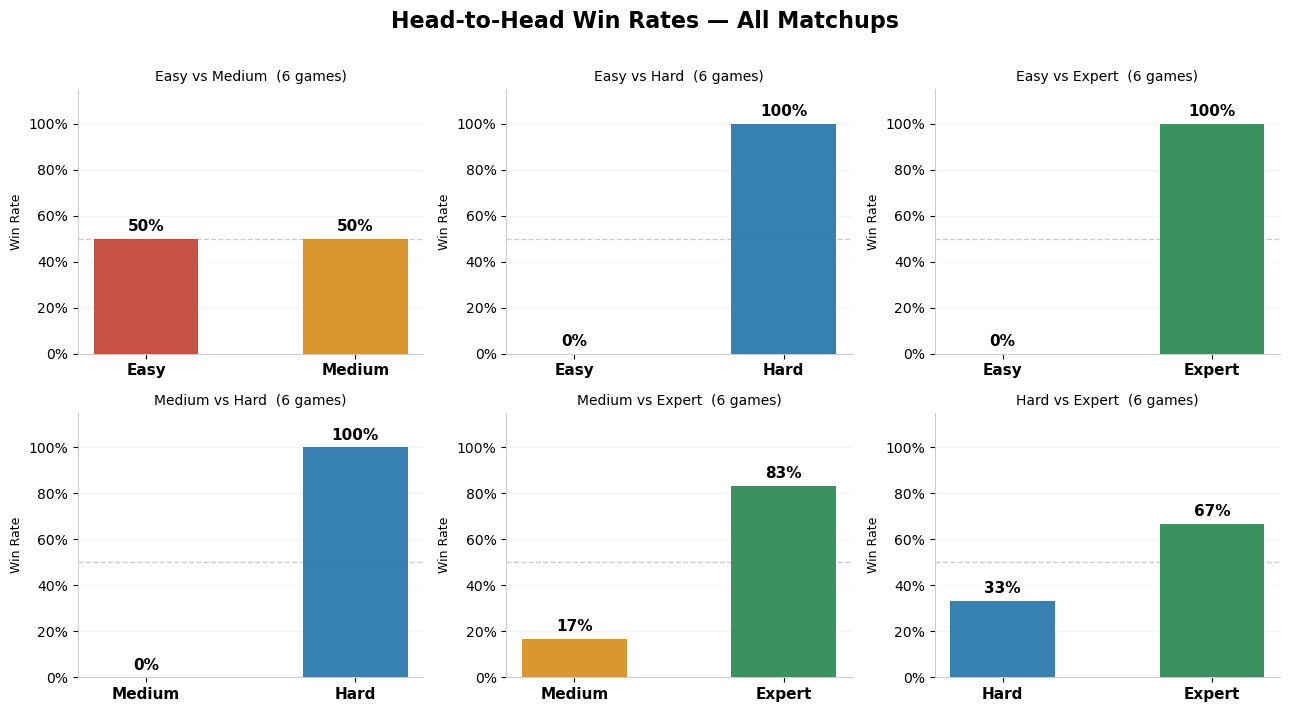

Saved: viz1_winrate_all_matchups.png


In [28]:
if not _check_results(ALL_KEYS): raise SystemExit

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.patch.set_facecolor("white")
fig.suptitle("Head-to-Head Win Rates — All Matchups",
             fontsize=16, fontweight="bold", color="black", y=1.01)

for ax, key in zip(axes.flat, ALL_KEYS):
    result = RESULTS[key]
    label_a, label_b = key
    win_rate_a = result["a_winrate"]
    win_rate_b = result["b_winrate"]

    bars = ax.bar(
        [0, 1], [win_rate_a, win_rate_b],
        color=[COLORS[label_a], COLORS[label_b]],
        width=0.5, zorder=3, alpha=0.88
    )

    for bar, win_rate in zip(bars, [win_rate_a, win_rate_b]):
        ax.text(
            bar.get_x() + bar.get_width() / 2, win_rate + 0.02,
            f"{win_rate:.0%}", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="black"
        )

    ax.axhline(0.5, color="gray", linewidth=1.0, linestyle="--", alpha=0.4, zorder=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([label_a, label_b], fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Win Rate", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(axis="y", zorder=1, alpha=0.4)
    ax.set_title(
        f"{label_a} vs {label_b}  ({result['n_games']} games)",
        fontsize=10, color="black", pad=6
    )
    ax.tick_params(colors="black")

plt.tight_layout()
plt.savefig("viz1_winrate_all_matchups.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz1_winrate_all_matchups.png")


### Visual 2 — Win Rate & Disc Margin

Win rate was 50/50 for Easy vs Medium — but the disc margin reveals Medium plays much stronger Othello. This visual shows both metrics together.

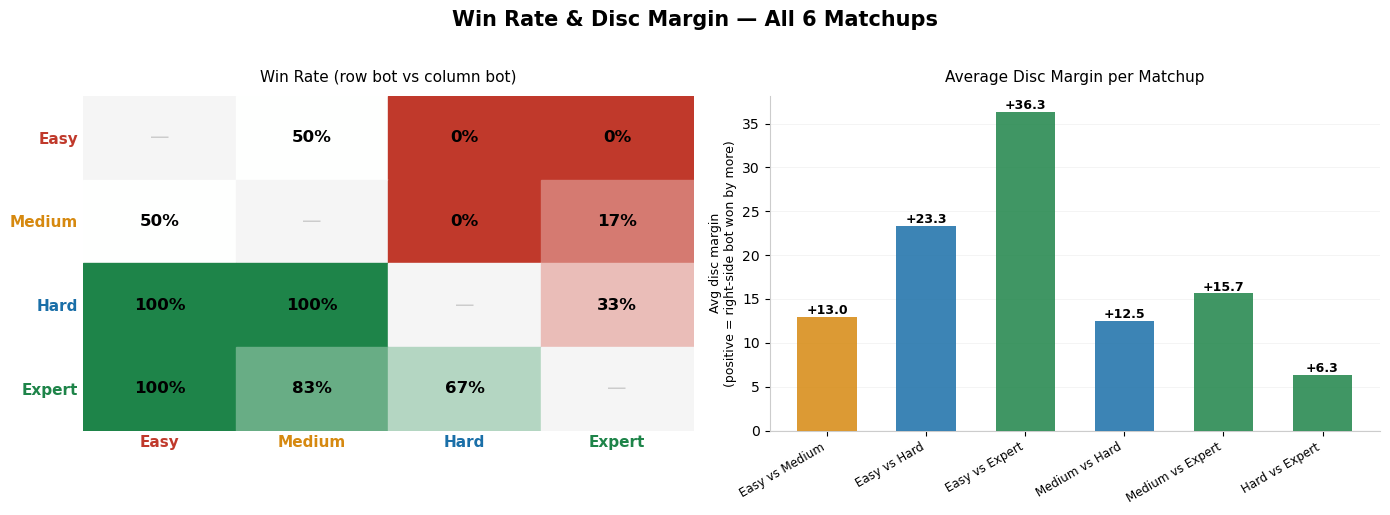

Saved: viz2_winrate_and_margin.png


In [29]:
if not _check_results(ALL_KEYS): raise SystemExit

fig, (ax_grid, ax_margin) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")
fig.suptitle("Win Rate & Disc Margin — All 6 Matchups",
             fontsize=15, fontweight="bold", color="black", y=1.02)

# ── Left: win rate grid ─────────────────────────────────────────────────────
bot_names = ["Easy", "Medium", "Hard", "Expert"]
n = len(bot_names)
win_rate_matrix = [[None] * n for _ in range(n)]
for key in ALL_KEYS:
    label_a, label_b = key
    i, j = bot_names.index(label_a), bot_names.index(label_b)
    win_rate_matrix[i][j] = RESULTS[key]["a_winrate"]
    win_rate_matrix[j][i] = RESULTS[key]["b_winrate"]

color_map = mcolors.LinearSegmentedColormap.from_list("wr", ["#C0392B", "#FFFFFF", "#1E8449"])
color_norm = mcolors.Normalize(vmin=0, vmax=1)

for row in range(n):
    for col in range(n):
        value = win_rate_matrix[row][col]
        if value is not None:
            cell_color = color_map(color_norm(value))
            ax_grid.add_patch(plt.Rectangle((col - 0.5, row - 0.5), 1, 1, color=cell_color, zorder=2))
            ax_grid.text(col, row, f"{value:.0%}", ha="center", va="center",
                         fontsize=12, fontweight="bold", color="black", zorder=3)
        else:
            ax_grid.add_patch(plt.Rectangle((col - 0.5, row - 0.5), 1, 1, color="#F5F5F5", zorder=2))
            ax_grid.text(col, row, "—", ha="center", va="center",
                         fontsize=14, color="#CCCCCC", zorder=3)

ax_grid.set_xlim(-0.5, n - 0.5)
ax_grid.set_ylim(-0.5, n - 0.5)
ax_grid.set_xticks(range(n))
ax_grid.set_xticklabels(bot_names, fontsize=11, fontweight="bold")
ax_grid.set_yticks(range(n))
ax_grid.set_yticklabels(bot_names, fontsize=11, fontweight="bold")
for i, name in enumerate(bot_names):
    ax_grid.get_xticklabels()[i].set_color(COLORS[name])
    ax_grid.get_yticklabels()[i].set_color(COLORS[name])
ax_grid.set_title("Win Rate (row bot vs column bot)", fontsize=11, pad=10)
ax_grid.invert_yaxis()
ax_grid.grid(False)
for spine in ax_grid.spines.values():
    spine.set_visible(False)
ax_grid.tick_params(length=0)

# ── Right: average disc margin bar chart ────────────────────────────────────
disc_margins = [-RESULTS[k]["avg_margin"] for k in ALL_KEYS]
bar_colors   = [COLORS[k[1]] for k in ALL_KEYS]
x_positions  = np.arange(len(ALL_LABELS))

margin_bars = ax_margin.bar(
    x_positions, disc_margins, color=bar_colors, alpha=0.85, zorder=3, width=0.6
)
for bar, margin in zip(margin_bars, disc_margins):
    ax_margin.text(
        bar.get_x() + bar.get_width() / 2,
        margin + (0.3 if margin >= 0 else -0.8),
        f"{margin:+.1f}", ha="center", fontsize=9,
        fontweight="bold", color="black"
    )

ax_margin.axhline(0, color="black", linewidth=0.8, alpha=0.3)
ax_margin.set_xticks(x_positions)
ax_margin.set_xticklabels(ALL_LABELS, rotation=30, ha="right", fontsize=8.5)
ax_margin.set_ylabel("Avg disc margin\n(positive = right-side bot won by more)", fontsize=9)
ax_margin.set_title("Average Disc Margin per Matchup", fontsize=11, pad=10)
ax_margin.grid(axis="y", zorder=1, alpha=0.4)

plt.tight_layout()
plt.savefig("viz2_winrate_and_margin.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz2_winrate_and_margin.png")


### Visual 3 — Simulations vs Strength

Shows how MCTS win rate against HeuristicBot scales with simulation count. More simulations = better search coverage = stronger play.

  [██████████████████████████████] 6/6 (100%)  MCTS-10 win rate so far: 33.3%
──────────────────────────────────────────────────
  MCTS-10 vs Heuristic  (6 games)
──────────────────────────────────────────────────
  MCTS-10              wins :    2  (33.3%)
  Heuristic            wins :    4  (66.7%)
  Draws                 :    0  (0.0%)
  Avg disc margin for MCTS- : -11.33
  sims=  10  win rate=33.33%
  [██████████████████████████████] 6/6 (100%)  MCTS-25 win rate so far: 16.7%
──────────────────────────────────────────────────
  MCTS-25 vs Heuristic  (6 games)
──────────────────────────────────────────────────
  MCTS-25              wins :    1  (16.7%)
  Heuristic            wins :    4  (66.7%)
  Draws                 :    1  (16.7%)
  Avg disc margin for MCTS- : -15.33
  sims=  25  win rate=16.67%
  [██████████████████████████████] 6/6 (100%)  MCTS-50 win rate so far: 50.0%
──────────────────────────────────────────────────
  MCTS-50 vs Heuristic  (6 games)
──────────────────────

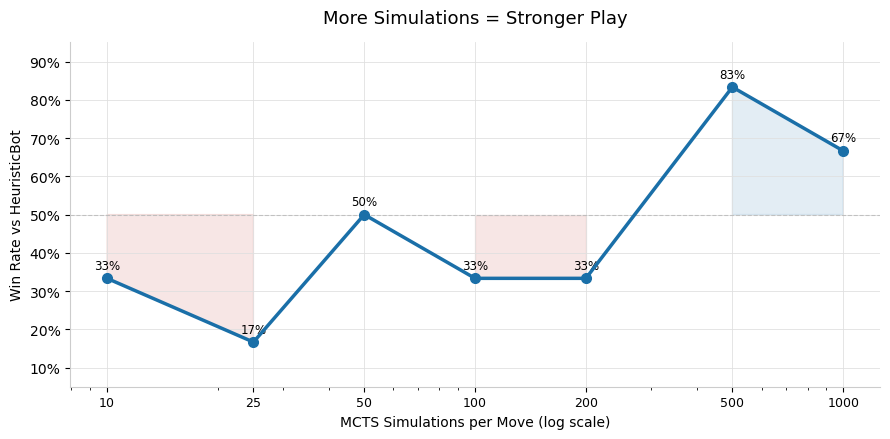

Saved: viz3_simulations_curve.png


In [30]:
# Runs real matchups at increasing simulation counts.
# Results are stored in RESULTS with temporary labels.
sim_counts  = []
sim_winrates = []
baseline = HeuristicBot()

for num_sims in [10, 25, 50, 100, 200, 500, 1000]:
    test_bot = MCTSBot(num_simulations=num_sims)
    result = evaluate_matchup(
        test_bot, baseline, n_games=6,
        label_a=f"MCTS-{num_sims}", label_b="Heuristic",
        progress_every=5, track_moves=False
    )
    sim_counts.append(num_sims)
    sim_winrates.append(result["a_winrate"])
    print(f"  sims={num_sims:4d}  win rate={result['a_winrate']:.2%}")

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor("white")

ax.plot(sim_counts, sim_winrates, color=COLORS["Hard"],
        linewidth=2.5, marker="o", markersize=7, zorder=4)
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.35, zorder=2)
ax.fill_between(sim_counts, 0.5, sim_winrates,
                where=[w >= 0.5 for w in sim_winrates],
                color=COLORS["Hard"], alpha=0.12, zorder=1)
ax.fill_between(sim_counts, sim_winrates, 0.5,
                where=[w < 0.5 for w in sim_winrates],
                color=COLORS["Easy"], alpha=0.12, zorder=1)

for num_sims, win_rate in zip(sim_counts, sim_winrates):
    ax.text(num_sims, win_rate + 0.025, f"{win_rate:.0%}", ha="center", fontsize=8.5, color="black")

ax.set_xscale("log")
ax.set_xlabel("MCTS Simulations per Move (log scale)", fontsize=10)
ax.set_ylabel("Win Rate vs HeuristicBot", fontsize=10)
ax.set_ylim(0.05, 0.95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xticks(sim_counts)
ax.set_xticklabels([str(s) for s in sim_counts], fontsize=9)
ax.grid(axis="both", zorder=1)
ax.set_title("More Simulations = Stronger Play", fontsize=13, pad=14, color="black")

plt.tight_layout()
plt.savefig("viz3_simulations_curve.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz3_simulations_curve.png")


### Visual 4 — Position Weight Heatmap

The hand-crafted weight table used by HeuristicBot and as the positional prior in our novel UCT bias term. Corners are most valuable; X-squares (diagonal to corners) are most dangerous.

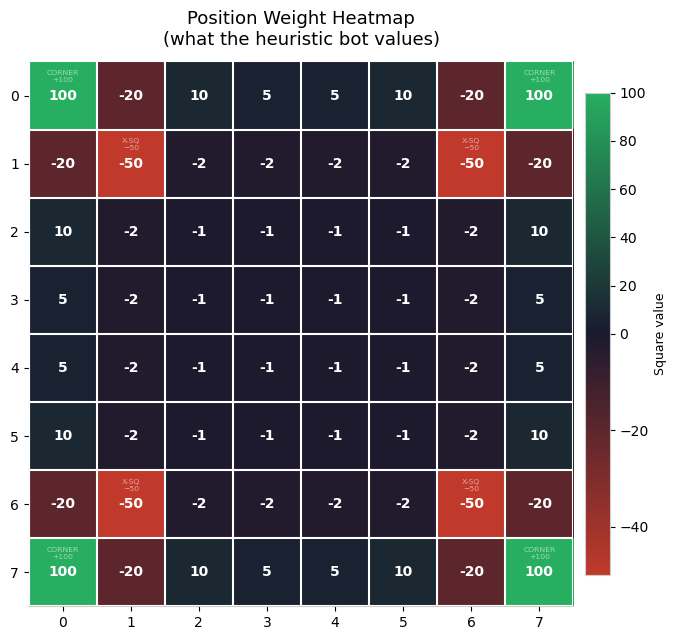

Saved: viz4_position_weight_heatmap.png


In [31]:
position_weights_array = np.array(POSITION_WEIGHTS, dtype=float)

fig, ax = plt.subplots(figsize=(7, 6.5))
fig.patch.set_facecolor("white")

color_map = mcolors.LinearSegmentedColormap.from_list(
    "othello_weights", ["#c0392b", "#1a1a2e", "#27ae60"], N=256
)
color_norm = mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=100)
im = ax.imshow(position_weights_array, cmap=color_map, norm=color_norm, zorder=2)

# Grid lines
for i in range(9):
    ax.axhline(i - 0.5, color="white", linewidth=1.5, zorder=3)
    ax.axvline(i - 0.5, color="white", linewidth=1.5, zorder=3)

# Value annotations on each square
for row in range(8):
    for col in range(8):
        weight_value = int(position_weights_array[row, col])
        ax.text(col, row, str(weight_value), ha="center", va="center",
                fontsize=10, fontweight="bold", color="white", zorder=4)

# Zone labels for corners and X-squares
zone_annotations = {
    (0, 0): "CORNER\n+100", (0, 7): "CORNER\n+100",
    (7, 0): "CORNER\n+100", (7, 7): "CORNER\n+100",
    (1, 1): "X-SQ\n−50",    (1, 6): "X-SQ\n−50",
    (6, 1): "X-SQ\n−50",    (6, 6): "X-SQ\n−50",
}
for (row, col), label in zone_annotations.items():
    ax.text(col, row - 0.28, label, ha="center", va="center",
            fontsize=5.5, color="white", alpha=0.55, zorder=5)

color_bar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
color_bar.set_label("Square value", color="black", fontsize=9)
plt.setp(color_bar.ax.yaxis.get_ticklabels(), color="black")

ax.set_xticks(range(8))
ax.set_xticklabels(list("01234567"))
ax.set_yticks(range(8))
ax.set_yticklabels(list("01234567"))
ax.set_title("Position Weight Heatmap\n(what the heuristic bot values)",
             fontsize=13, color="black", pad=12)

plt.tight_layout()
plt.savefig("viz4_position_weight_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz4_position_weight_heatmap.png")


### Visual 5 — Move Frequency Heatmaps

Where each bot actually places its pieces across all evaluation games. Move frequencies are pooled from all matchups each bot appeared in. Corner play percentages reveal how differently each strategy values board position.

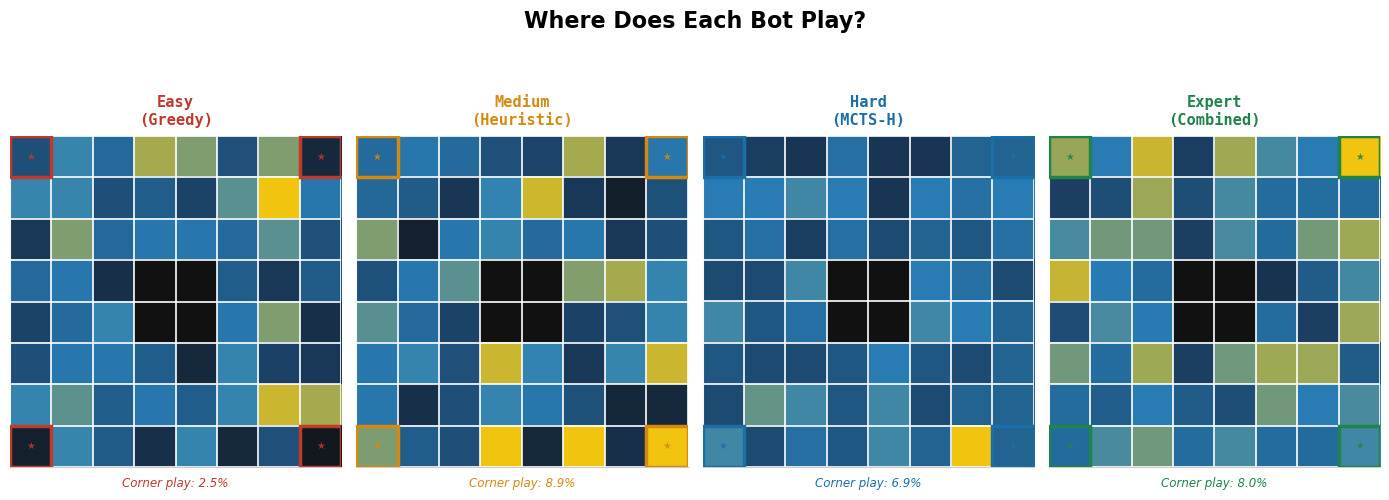

Saved: viz5_move_frequency_heatmaps.png


In [32]:
if not _check_results(ALL_KEYS): raise SystemExit


def pool_frequencies(*freq_arrays):
    """
    Average a set of 8×8 move frequency arrays into a single normalised heatmap.

    Each input array is already normalised to 100%. The combined array is
    re-normalised after summing so the output also sums to 100%.

    Args:
        *freq_arrays: Variable number of 8×8 numpy arrays.

    Returns:
        8×8 numpy array normalised to sum to 100.
    """
    combined = sum(freq_arrays)
    total = combined.sum() or 1
    return combined / total * 100


# Pool each bot's frequencies from all matchups it appeared in
freq_easy = pool_frequencies(
    RESULTS[("Easy", "Medium")]["freq_a"],
    RESULTS[("Easy", "Hard")]["freq_a"],
    RESULTS[("Easy", "Expert")]["freq_a"],
)
freq_medium = pool_frequencies(
    RESULTS[("Easy",   "Medium")]["freq_b"],
    RESULTS[("Medium", "Hard")]["freq_a"],
    RESULTS[("Medium", "Expert")]["freq_a"],
)
freq_hard = pool_frequencies(
    RESULTS[("Medium", "Hard")]["freq_b"],
    RESULTS[("Easy",   "Hard")]["freq_b"],
    RESULTS[("Hard",   "Expert")]["freq_a"],
)
freq_expert = pool_frequencies(
    RESULTS[("Hard",   "Expert")]["freq_b"],
    RESULTS[("Easy",   "Expert")]["freq_b"],
    RESULTS[("Medium", "Expert")]["freq_b"],
)

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.patch.set_facecolor("white")

bot_display_labels = ["Easy\n(Greedy)", "Medium\n(Heuristic)", "Hard\n(MCTS-H)", "Expert\n(Combined)"]
frequency_arrays   = [freq_easy, freq_medium, freq_hard, freq_expert]
bot_display_colors = [COLORS["Easy"], COLORS["Medium"], COLORS["Hard"], COLORS["Expert"]]
corner_positions   = [(0, 0), (0, 7), (7, 0), (7, 7)]

heatmap_cmap = mcolors.LinearSegmentedColormap.from_list(
    "move_freq", ["#111111", "#1a3a5c", "#2980b9", "#f1c40f"]
)

for ax, freq, label, color in zip(axes, frequency_arrays, bot_display_labels, bot_display_colors):
    ax.imshow(freq, cmap=heatmap_cmap, vmin=0, vmax=freq.max(), zorder=2)

    for i in range(9):
        ax.axhline(i - 0.5, color="white", linewidth=1.2, zorder=3)
        ax.axvline(i - 0.5, color="white", linewidth=1.2, zorder=3)

    for (row, col) in corner_positions:
        ax.add_patch(plt.Rectangle((col - 0.5, row - 0.5), 1, 1,
                     fill=False, edgecolor=color, linewidth=2.5, zorder=4))
        ax.text(col, row, "★", ha="center", va="center",
                fontsize=7, color=color, zorder=5, alpha=0.85)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(label, fontsize=11, color=color, pad=8,
                 fontweight="bold", fontfamily="monospace")

    corner_pct = sum(freq[row, col] for row, col in corner_positions)
    ax.text(0.5, -0.06, f"Corner play: {corner_pct:.1f}%",
            transform=ax.transAxes, ha="center", fontsize=8.5,
            color=color, style="italic")

fig.suptitle("Where Does Each Bot Play?",
             fontsize=16, fontweight="bold", color="black", y=1.02)
plt.tight_layout(rect=[0, 0.0, 1, 0.95])
plt.savefig("viz5_move_frequency_heatmaps.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz5_move_frequency_heatmaps.png")


### Visual 6 — Random vs Heuristic Rollout

Compares MCTS with random rollouts versus heuristic rollouts at identical simulation budgets. The gap reveals the value of rollout quality — especially at low budgets where random rollout barely beats chance.

In [34]:
# ── Data collection ────────────────────────────────────────────────────────────
# Runs both rollout variants at each simulation budget against a fixed HeuristicBot.
# Takes several minutes to complete.
sim_budgets    = []
wr_random      = []
wr_heuristic   = []
baseline = HeuristicBot()

for num_sims in [25, 50, 100, 200, 500]:
    result_random = evaluate_matchup(
        MCTSBot(num_simulations=num_sims), baseline, n_games=3,
        label_a=f"MCTS-rand-{num_sims}", label_b="Heuristic",
        progress_every=1, track_moves=False
    )
    result_heuristic = evaluate_matchup(
        MCTSHeuristicBot(num_simulations=num_sims), baseline, n_games=3,
        label_a=f"MCTS-heur-{num_sims}", label_b="Heuristic",
        progress_every=5, track_moves=False
    )
    sim_budgets.append(num_sims)
    wr_random.append(result_random["a_winrate"])
    wr_heuristic.append(result_heuristic["a_winrate"])
    print(f"  sims={num_sims:4d}  random={result_random['a_winrate']:.2%}  heuristic={result_heuristic['a_winrate']:.2%}")

print("\nData collection complete.")


  [██████████████████████████████] 3/3 (100%)  MCTS-rand-25 win rate so far: 33.3%
──────────────────────────────────────────────────
  MCTS-rand-25 vs Heuristic  (3 games)
──────────────────────────────────────────────────
  MCTS-rand-25         wins :    1  (33.3%)
  Heuristic            wins :    2  (66.7%)
  Draws                 :    0  (0.0%)
  Avg disc margin for MCTS- : -3.33
  [██████████████████████████████] 3/3 (100%)  MCTS-heur-25 win rate so far: 0.0%
──────────────────────────────────────────────────
  MCTS-heur-25 vs Heuristic  (3 games)
──────────────────────────────────────────────────
  MCTS-heur-25         wins :    0  (0.0%)
  Heuristic            wins :    3  (100.0%)
  Draws                 :    0  (0.0%)
  Avg disc margin for MCTS- : -32.00
  sims=  25  random=33.33%  heuristic=0.00%
  [██████████████████████████████] 3/3 (100%)  MCTS-rand-50 win rate so far: 100.0%
──────────────────────────────────────────────────
  MCTS-rand-50 vs Heuristic  (3 games)
────────

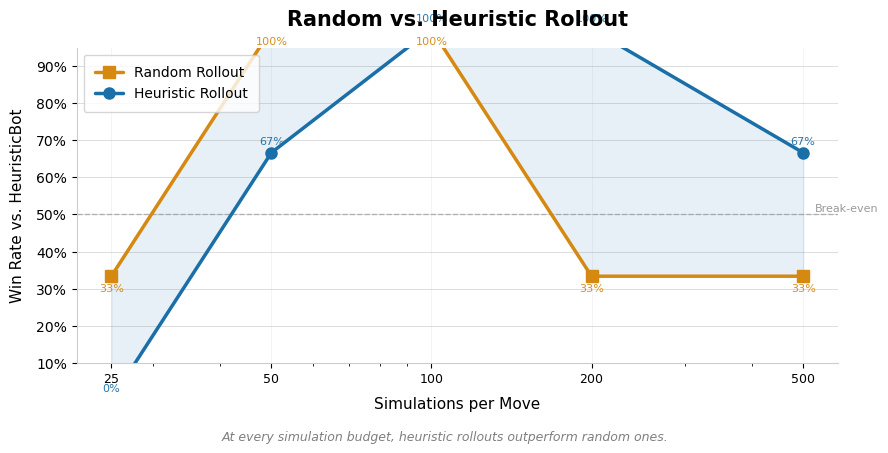

Saved: viz6_rollout_comparison.png


In [35]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.plot(sim_budgets, wr_random, color=COLORS["Medium"], linewidth=2.5,
        marker="s", markersize=8, label="Random Rollout", zorder=4, solid_capstyle="round")
ax.plot(sim_budgets, wr_heuristic, color=COLORS["Hard"], linewidth=2.5,
        marker="o", markersize=8, label="Heuristic Rollout", zorder=4, solid_capstyle="round")

ax.axhline(0.5, color="gray", linewidth=1.0, linestyle="--", alpha=0.5, zorder=2)
ax.text(sim_budgets[-1] * 1.05, 0.502, "Break-even",
        fontsize=8, color="gray", alpha=0.8, va="bottom")

ax.fill_between(sim_budgets, wr_random, wr_heuristic,
                color=COLORS["Hard"], alpha=0.10, zorder=1)

for num_sims, rand_wr, heur_wr in zip(sim_budgets, wr_random, wr_heuristic):
    ax.text(num_sims, rand_wr - 0.042, f"{rand_wr:.0%}",
            ha="center", fontsize=8, color=COLORS["Medium"], alpha=0.95)
    ax.text(num_sims, heur_wr + 0.022, f"{heur_wr:.0%}",
            ha="center", fontsize=8, color=COLORS["Hard"], alpha=0.95)

ax.set_xscale("log")
ax.set_xlabel("Simulations per Move", fontsize=11, labelpad=8, color="black")
ax.set_ylabel("Win Rate vs. HeuristicBot", fontsize=11, labelpad=8, color="black")
ax.set_ylim(0.10, 0.95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xticks(sim_budgets)
ax.set_xticklabels([str(s) for s in sim_budgets], fontsize=9, color="black")
ax.tick_params(colors="black")
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_color("#CCCCCC")
ax.grid(axis="y", zorder=1, alpha=0.3, color="gray")
ax.grid(axis="x", zorder=1, alpha=0.1, color="gray")

legend = ax.legend(frameon=True, fontsize=10, loc="upper left",
                   borderpad=0.8, handlelength=2)
for text in legend.get_texts():
    text.set_color("black")
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#CCCCCC")

ax.set_title("Random vs. Heuristic Rollout", fontsize=15, pad=16,
             color="black", fontweight="bold")
fig.text(0.5, 0.01,
         "At every simulation budget, heuristic rollouts outperform random ones.",
         ha="center", fontsize=9, color="black", alpha=0.5, style="italic")

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("viz6_rollout_comparison.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz6_rollout_comparison.png")


## 8. Play a Game — Human vs Bot

Set `DIFFICULTY` to `"easy"`, `"medium"`, `"hard"`, or `"expert"` and
`HUMAN_COLOR` to `BLACK` (first mover) or `WHITE`.
Then run the cell and follow the prompts — enter moves as `row,col` (0-indexed), e.g. `2,3`.

In [36]:
# ── Configuration ──────────────────────────────────────────────────────────────
DIFFICULTY   = "medium"   # "easy", "medium", "hard", or "expert"
HUMAN_COLOR  = BLACK      # BLACK (goes first) or WHITE

BOTS = {
    "easy":   GreedyBot(),
    "medium": HeuristicBot(),
    "hard":   MCTSHeuristicBot(num_simulations=200),
    "expert": MCTSCombinedBot(num_simulations=500, tdl_weight=PRETRAINED_W),
}

active_bot = BOTS[DIFFICULTY]
bot_color  = -HUMAN_COLOR
game       = Othello()


def player_label(player: int) -> str:
    """Return a human-readable label for a player token."""
    return "BLACK (you)" if player == HUMAN_COLOR else f"WHITE ({DIFFICULTY} bot)"


print(f"You are playing as {'BLACK' if HUMAN_COLOR == BLACK else 'WHITE'}.")
print(f"Bot difficulty: {DIFFICULTY.upper()}\n")

while not game.is_game_over():
    game.print_board()
    current_player = game.current_player
    legal_moves    = game.get_legal_moves(current_player)
    print(f"\nTurn: {player_label(current_player)}")

    if not legal_moves:
        print("No legal moves — passing.")
        game.apply_move(None)
        continue

    if current_player == bot_color:
        chosen_move = active_bot.choose_move(game.clone(), current_player)
        print(f"Bot plays: {chosen_move}")
    else:
        print("Legal moves:", legal_moves)
        while True:
            raw_input = input("Your move (row,col): ").strip()
            try:
                row, col = map(int, raw_input.split(","))
                chosen_move = (row, col)
            except ValueError:
                print("Format: row,col  e.g. 2,3")
                continue
            if chosen_move in legal_moves:
                break
            print("Illegal move — please try again.")

    game.apply_move(chosen_move)

print("\n" + "=" * 30)
game.print_board()
winner = game.get_winner()
score  = game.get_score()
print(f"\nFinal score — Black: {score['black']}  White: {score['white']}")
if winner == HUMAN_COLOR:
    print("You win!")
elif winner == -HUMAN_COLOR:
    print(f"The {DIFFICULTY} bot wins!")
else:
    print("It's a draw!")


You are playing as BLACK.
Bot difficulty: MEDIUM

  0 1 2 3 4 5 6 7
0 . . . . . . . .
1 . . . . . . . .
2 . . . . . . . .
3 . . . W B . . .
4 . . . B W . . .
5 . . . . . . . .
6 . . . . . . . .
7 . . . . . . . .

Turn: BLACK (you)
Legal moves: [(2, 3), (3, 2), (4, 5), (5, 4)]


Your move (row,col):  3,2


  0 1 2 3 4 5 6 7
0 . . . . . . . .
1 . . . . . . . .
2 . . . . . . . .
3 . . B B B . . .
4 . . . B W . . .
5 . . . . . . . .
6 . . . . . . . .
7 . . . . . . . .

Turn: WHITE (medium bot)
Bot plays: (2, 2)
  0 1 2 3 4 5 6 7
0 . . . . . . . .
1 . . . . . . . .
2 . . W . . . . .
3 . . B W B . . .
4 . . . B W . . .
5 . . . . . . . .
6 . . . . . . . .
7 . . . . . . . .

Turn: BLACK (you)
Legal moves: [(1, 2), (2, 3), (4, 5), (5, 4)]


Your move (row,col):  2,3


  0 1 2 3 4 5 6 7
0 . . . . . . . .
1 . . . . . . . .
2 . . W B . . . .
3 . . B B B . . .
4 . . . B W . . .
5 . . . . . . . .
6 . . . . . . . .
7 . . . . . . . .

Turn: WHITE (medium bot)
Bot plays: (2, 4)
  0 1 2 3 4 5 6 7
0 . . . . . . . .
1 . . . . . . . .
2 . . W W W . . .
3 . . B B W . . .
4 . . . B W . . .
5 . . . . . . . .
6 . . . . . . . .
7 . . . . . . . .

Turn: BLACK (you)
Legal moves: [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 5), (3, 5), (4, 5), (5, 5)]


...

  0 1 2 3 4 5 6 7
0 B B B B B B B W
1 B B B B B B B W
2 B B B W W W B W
3 B W B B W W B W
4 B B B B B W B W
5 B B B W B B B W
6 . . B B B B B W
7 . B B B B B B .

Turn: WHITE (medium bot)
Bot plays: (6, 0)
  0 1 2 3 4 5 6 7
0 B B B B B B B W
1 B B B B B B B W
2 B B B W W W B W
3 B W B W W W B W
4 B B W B B W B W
5 B W B W B B B W
6 W . B B B B B W
7 . B B B B B B .

Turn: BLACK (you)
Legal moves: [(6, 1), (7, 0)]


Your move (row,col):  7,0


  0 1 2 3 4 5 6 7
0 B B B B B B B W
1 B B B B B B B W
2 B B B W W W B W
3 B W B W W W B W
4 B B W B B W B W
5 B W B W B B B W
6 B . B B B B B W
7 B B B B B B B .

Turn: WHITE (medium bot)
Bot plays: (7, 7)
  0 1 2 3 4 5 6 7
0 B B B B B B B W
1 B B B B B B B W
2 B B B W W W B W
3 B W B W W W B W
4 B B W B W W B W
5 B W B W B W B W
6 B . B B B B W W
7 B B B B B B B W

Turn: BLACK (you)
Legal moves: [(6, 1)]


Your move (row,col):  6,1



  0 1 2 3 4 5 6 7
0 B B B B B B B W
1 B B B B B B B W
2 B B B W W W B W
3 B W B W W W B W
4 B B W B W W B W
5 B B B W B W B W
6 B B B B B B W W
7 B B B B B B B W

Final score — Black: 43  White: 21
You win!
